# Introduction to Denoising Diffusion Implicit Generative Models

## Stephen Elston

## Overview

Though these exercises you will gain some basic understanding of **denoising deffusion implicit models (DDIMs)**. DDIMs are image generative models which synthesize high quality images.  

## Running the Example Code     

For the exercises you will first need to run the code in this [Keras example notebook by Andres Beres](https://keras.io/examples/generative/ddim/). To run the notebook you will need a [Google Colabratory account](https://colab.research.google.com/) if you do not already have one. Log into your google account. From the Keras example page click the `View in Colab` tab to start the notebook in Colab (but do not execute yet!). Alternatively, you may want to run this notebook locally, if you have the resources.     

On several tests with Colab and Colab Pro+ this notebook executed in under 1 hour with no time outs. If you enconter problems, please reach out to the instructional staff.  

The next section outlines changes you will need to make in this notebook.  

## Configuring Runtime

It is recommended that you configure your at either of:     
- L4 GPU
- T4 GPU

Use `High-RAM`.   

If you wish to change the runtime environment, use the pulldown to display this box, from which you can select your runtime.   

<img src="../img/ColabChangeRuntime.png" alt="Drawing" style="width:500px; height:300px"/>
<center>Box for configuring Colab runtime environment</center>     

## Updates to the Code

The Denoising Diffusion Implicit Modle notebook available in Keras Examples was created using Keras 2.X. Modifications are required to run this notebook under Keras 3.X. Please make the indicated updates.

### 1. Verify versions of TensorFlow and Keras

To ensure that you are using TensorFlow verion 2.18.0 or above and Keras version 3.8.0 or above add the code in the cell below to the end or the code cell with the imports.   

### 2. Add call methods to Diffusion Model    

The last method defined in the notebook for the `DiffusionModel` class is `plot_images`. To run under Keras 3.8 an explicit `call` method must be added. Append the code shown below to the code for the `DiffusionModel` class. 

### 3. Add explicity model building step and capture training history   

To run this notebook with Keras 3.8 the model must be built explicitly. Code to build the model is added following the compile step in the cell below.  

In order to investigate the training further, the history is saved in dictionary named `train_history`.

The code in the cell below should replace the code in the **Trsaining** section of the notebook.   

### 4. Plotting the training history

To display the training history for the model add a new code cell below the cell with the training code. Paste the code shown below into this cell.    

## Exercises     

With the notebook updated carefully read the explainatory text provided by the author. Then, execute the code and answer the questions in the following exercises.   

> 🚩❓ **Exercise 11-1:** In the DiffusionModel class examine the code in the `diffusion_schedule` method. Also, read the discussion in the diffusion schedule subsection of the text. What can you say about the rate of the increase of the added noise, $\epsilon_t$, in the steps of the forward diffusion process?                  

> ✅ **Answers:** The rate of the increase of the added noise can be seen as noise level derivative, $\epsilon_t$ is $Cos(\text{Diffusion Angle})$, since the added noise level changes as $Sin(\text{Diffusion Angle})$, which means added noise "inrease rate" is maximum and the beginning, slowing down towards the last steps (where the diffusion angle approaches 90 degrees):
> 
> 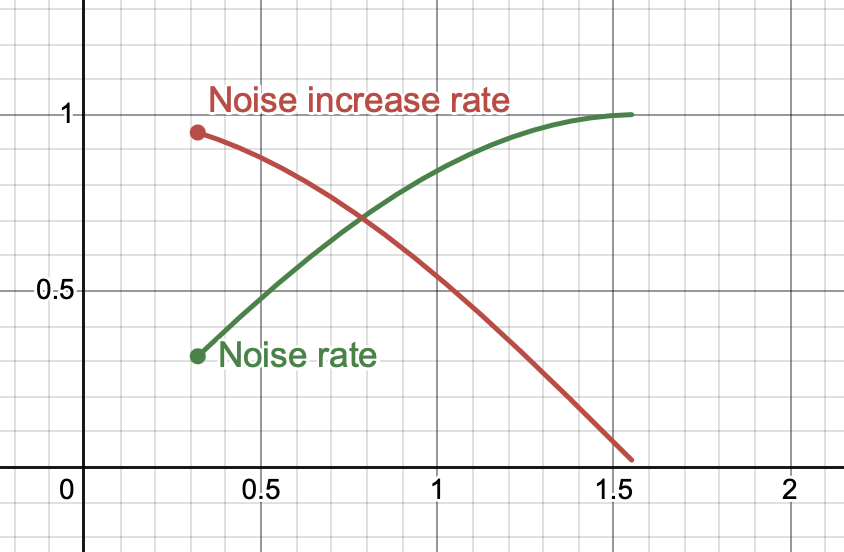
>
> Generally this noise/signal schedule is symmetric, by the design for the diffusion angle $\in(0,180)\degree$ , but with current choice of min and max signal rates we start with non-zero noise rate and finish with ~0 signal rate. This happens since the $\text{Diffusion Angle} \in \ \sim [ 18\degree, 89\degree]$ as being calculated in $[ArcCos(\text{max signal rate = 0.95}), ArcCos(\text{min signal rate = 0.02})]$

> 🚩❓ **Exercise 11-2:** Examine the code in the `denoise` method. This method is called at each revserse diffusion step in the `reverse_diffusion` method. Notice the if statement that switches btween training the neural network or sampling. Answer the following questions:    
> 1. During training, what component of the diffusion model is the neural network learning to predict?    
> 2. How is the predicted noise used in the denoising proceses.   
> 3. How are the signal rate and noise rates comptued by the `diffusion_schedule` method used to update the noise image?     

> ✅ **Answers:**     
> 1. During training, the diffusion model neural network learns to predict noise.
> 2. Denoising process, in the `denoise(...)` method of the `DiffusionModel` class calculates the predicted images via the reverted noisy image generating formula `noisy_images = signal_rates * images + noise_rates * noises`, inverting it: $$\text{predicted images} = \frac{\text{noisy images - noise rates} \times \text{pred noises}}{\text{ signal rates}}$$
> 3. The `diffusion_schedule` method computes signal and noise rates as $Cos$ and $Sin$ of the `diffusion_angle` values which by design variates randomly within $(0, 90)\degree$ between epochs for training and gradually increases for image generation, keeping $\text{noisy signal power} \equiv1$:
>   
>    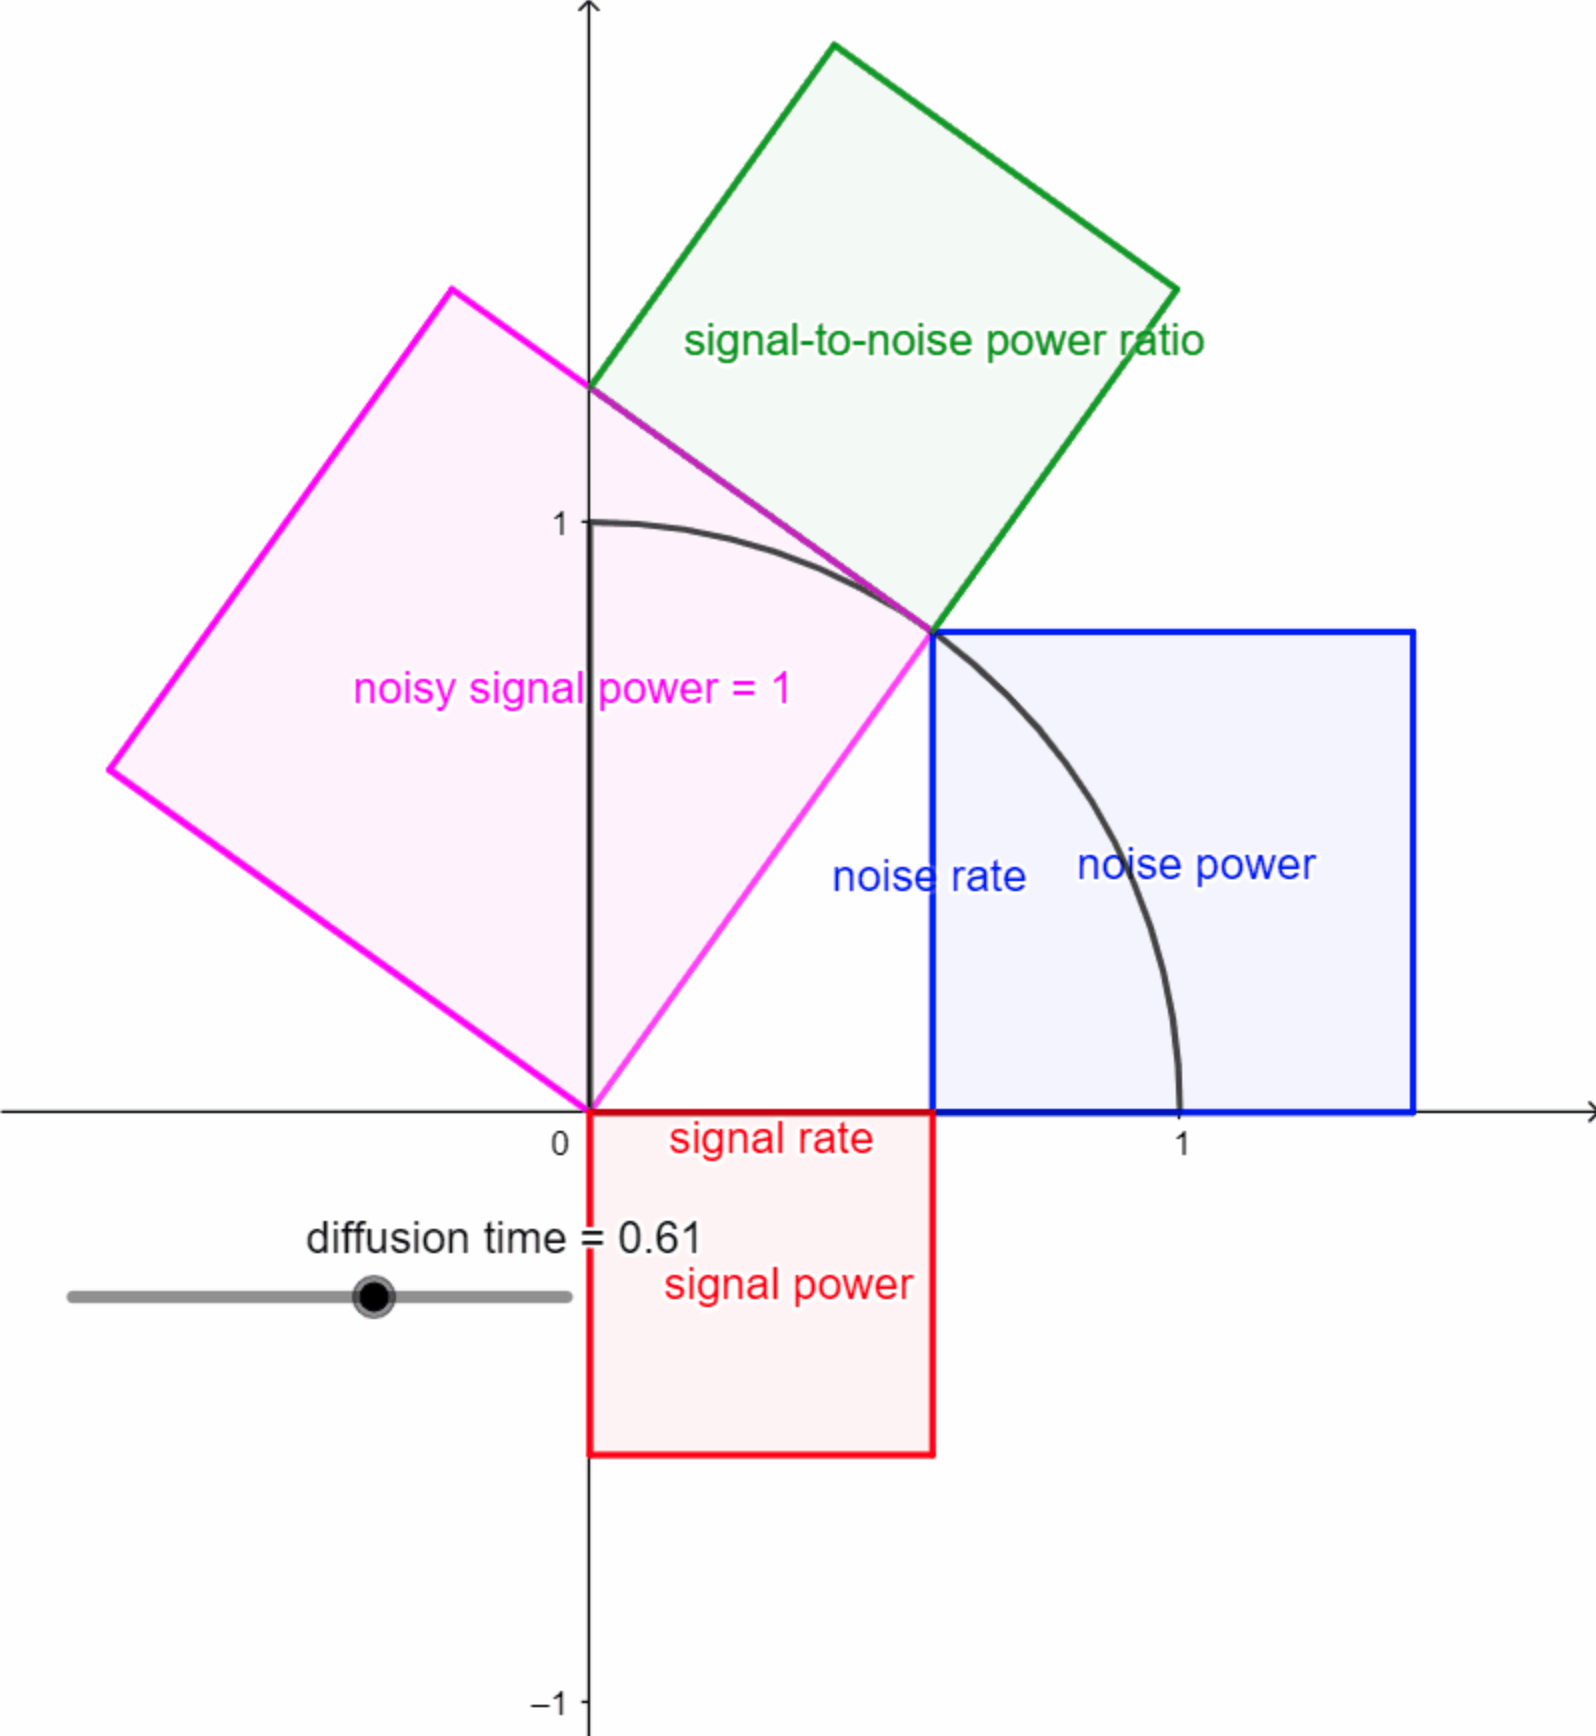

> 🚩❓ **Exercise 11-3::** The code shown below is copied from the `train_step` method of the DiffusionModel class.   

> In a few sentances, explain how this code implements the forward steps of the random diffusion process?           

> ✅ **Answer:**
>
> This code generates noisy images using `signal`/`noise` rate coeeficients for from `image`/`noise` linear combination. `Image`/`Noise` coefficients in their turn are generated randomly per batch in such a way that their quadratic sum is always equat to one. This works this way by assigning them Cos/Sin values of a batch `diffusion_angle`, which is losely speaking a random value within $(0, \pi)$.
>
> More formally (for the love of it), this logic unfolds as follows:
> 
> 1. `diffusion_time` $\leftarrow Unif(0, 1)$
> 2. `diffusion_angle` $\leftarrow$ `diffusion_time` linear interpolation between $arcCos(\text{max signal rate}) \text{ and } arcCos(\text{min signal rate})$
> 3. `signal`/`noise` rates $\leftarrow$ $Cos/Sin$ of `diffusion_angle`
> 4. `noisy image` $\leftarrow$ `image`/`noise` linear combination on `signal`/`noise` rates
> 
> Or, by collapsing all these steps into one formula:
> 
> $
\text{img}_\text{noisy} = 
\text{img} \times Cos(\alpha_d) +
\text{noise} \times Sin(\alpha_d)
$
> 
> Where:
> 
> - diffusion angle: $\alpha_d \ $=$\ arcCos(r_b) + u( arcCos(r_a) - arcCos(r_b))$
> - diffusion times: u ~ $Unif(0, 1)$
> - min_signal_rate: $r_a$
> - max_signal_rate: $r_b$

> 🚩❓ **Exercise 11-4:** Examine the code in the **Training** code cell. What loss function is used, and what error is being learned?              

> ✅ **Answers:** The `Training` code cell uses MAE as a loss function. The loss function in `Training` code cell calculates error of noise VS predicted noise and image VS predicted image. Overall model uses predicted image loss as a performance metric only. Noise VS predicted noise MAE loss is being used for the model training.

> 🚩❓ **Exercise 11-5:** Examine the squence of generated images produced in the history of the training epochs.These images represent the end product of the denoising Markov chain.
> 1. What do the images produced in the first few epochs tell you about the learning of the denoising process parameters?
> 2. Given the quality of the images in the laast few epochs what can you say about the neural network's ability to learn the noise parameters, $\epsilon_\theta$?      

> ✅ **Answers:**        
> 1. The images produced in the first few epochs show that the denoising process parameters aren't lerned yet on a level sufficient to produce recognizable results. Nevertheless, even the first three epochs images show discernible evolution. On the following steps, the noise nature changes, and becomes less uniform, demonstrating clasterization effects, gradually progressing towards full fledged flower images.
> 2. The last few epochs images and their background aren't discernible from a real images, which implies that the network has reasonably good ability to learn noise parameters, given training of at least 50 epochs:
>
>    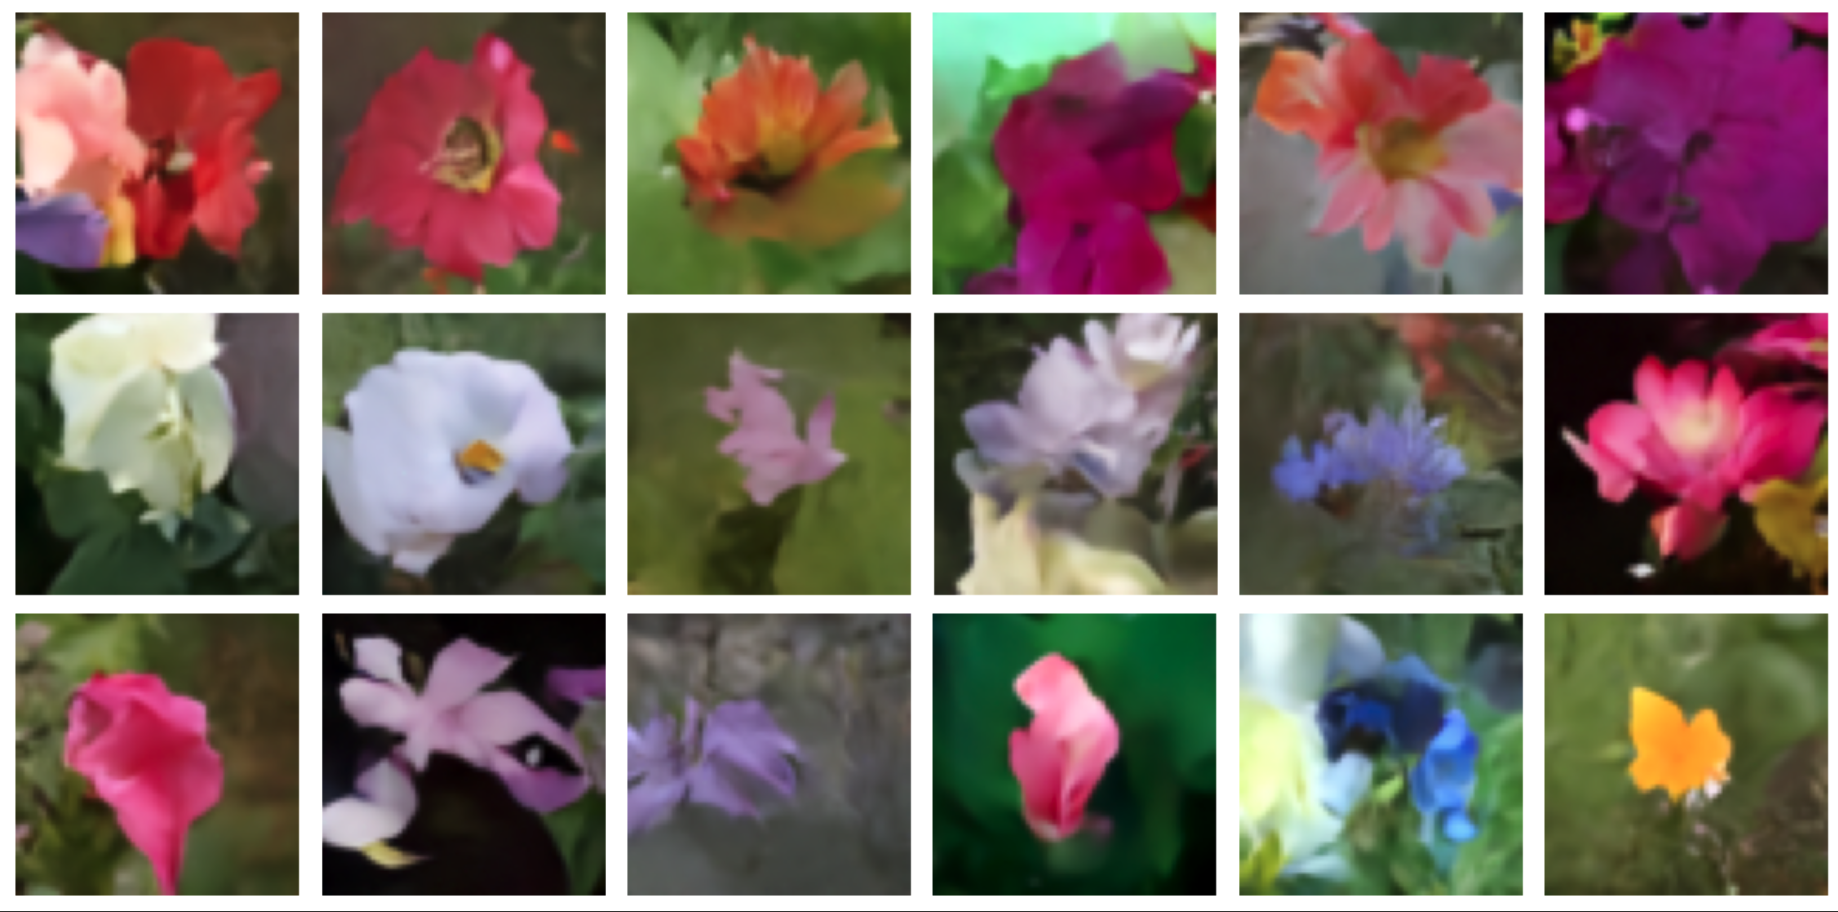

> 🚩❓ **Exercise 11-6:**  Examine the images produced by the best trained model in the Inference section of the notebook. All of the images are of floweres. However, there is no guidance indicating the images produced should be of flowers.    
> 1. Considering the training images, why do you think only flower images are created?
> 2. What are the implications of your answer to the above question in terms the distributions required for creating a diffusion image generative model that can create a wide range of images?
> 3. What are the limitations you have just discussed have for the general ability of generative diffusion models to produce arbitrary iamges in practice?       
> **End of exercise.**  

> ✅ **Answers:**
> 1. The model only generates flowers, because it is trained on the `oxford_flowers102`, which consists of flowers only. So the model has only had chance to learn how to generate flowers.
> 2. The distribution required for creating diffusion image should be locally clastered, continuous and separable, since generated objects of the same class shouldn't be far from each other, while different classes should occupy different separable subspaces (manifolds).
> 3. The generative diffusion models ability to generate images is limited by the data it was trained on - they can only use features and their combinations that they've seen during training, as well as dimensions of the data that it is designed to work with. Additionally, if the data has bias, for instance, asian people only, the generative model will inherit it. Image generation is computation and memory consumption heavy. That is due to the model architecture and multiple passes for the initial 100% noisy image needs to transform into a real image.

> 🚩❓ **Exercise 11-7:** Examine the three plots produced from the training metrics and answer the following questions.     
> 1. Is the monotonic decrease in noise loss expected given the training algorithm and why?
> 2. Image loss measures the difference between the training imaage and the denoising image. This metric is not used to learn the model, but only for monitoring the training. Why does the general shape of the image loss curve closely resemble the noise loss curve?
> 3. The kernel inception distance (KDI) curve does not decrease monotonically. Is this behavior reasonable as the model learns and why?
> 4. Given the noise loss, image loss and KDI curves does it appear that the training of the model has largely converged?    

> ✅ **Answers:**      
> 1. The monotonic loss decrease is reasonable, since the denoising U-Net netowrk trains to predict noise better and better with every iteration, gradually decreasing loss along the epochs. At the same I can't say that is guaranteed. Comparing generated images between epochs 15 and 50 shows that most of the time in that period model learns to generate backgrounds, while before it was learning to generate flowers. One can assume that since this looks like a step process, the loss can demonstrate a similar nature. 
> 2. The general shape of the image loss curve closely resemble the noise loss curve, since both losses measure pixel differences between the predicted image/noise and the ground truth, while the denoised image is created as a linear combination of predicted noise and the ground truth image. That's why we can say that the denoised image and ground truth image differences are strongly correlated with predicted and the ground truth noise difference. AAaand that's why image loss curve shape closely resemble the noise loss curve.
> 3. Overall, the kernel inception distance should correlate with the noise prediction loss, at the same time the model trains and optimizes itself with respect to noise prediction, improving overall image quality and feature composition indirectly. Therefore, there can be lags between kernel inception distance and noise prediction loss decrease, and even some eventual cases, when loss goes down, while kernel inception distance goes up due to well denoised, but incorrect image feature locations/distribution.
> 4. Given the noise loss, image loss and kernel inception distance curves it does appear that the training of the model has converged. Both losses monotonously go down almost platoeing around epoch 10, while kernel inception distance catches up with them around epoch 15, probably due to the reason listed in the previous question:
>    
>    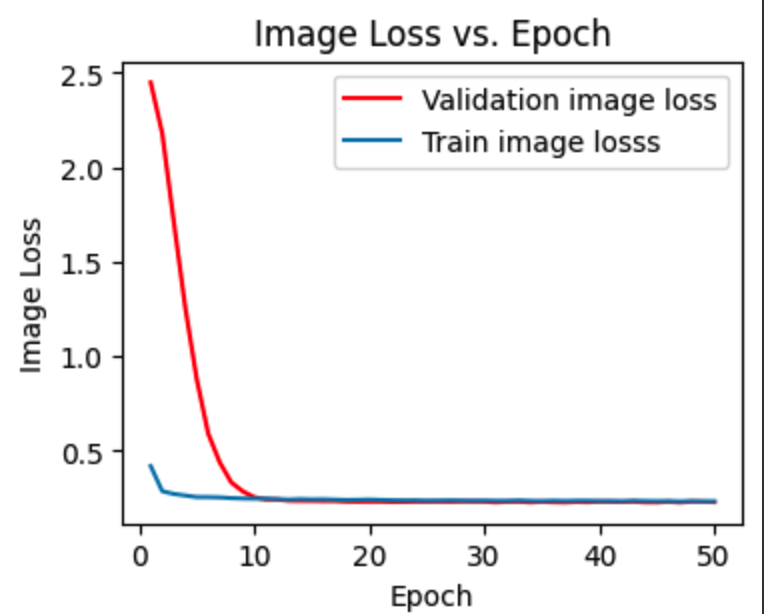
>    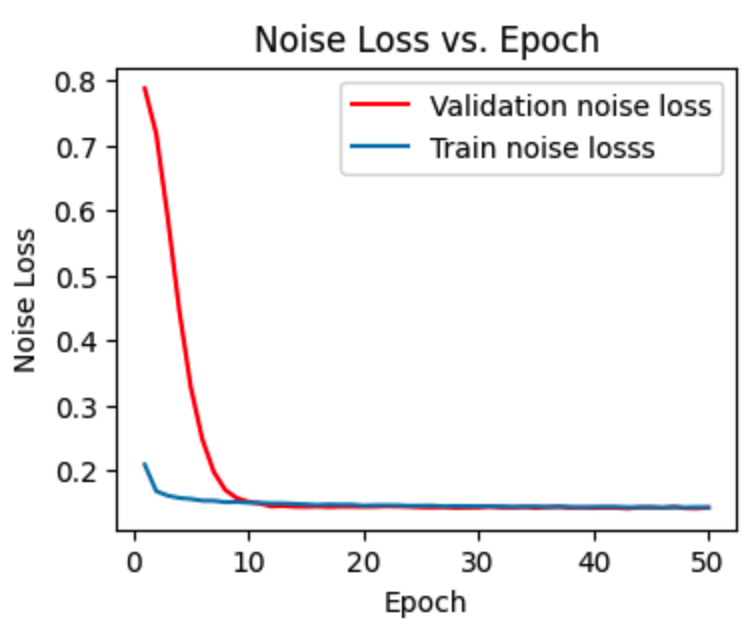
>    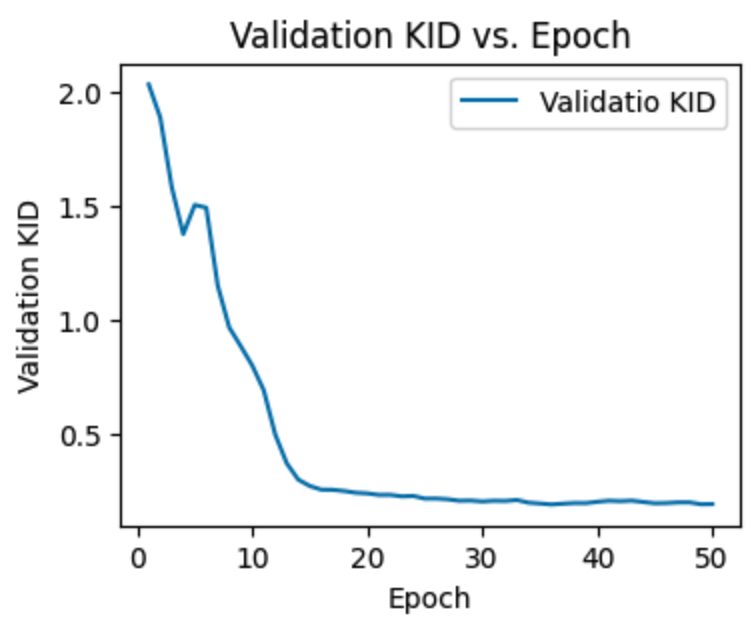

## For Further Exploration     

You can find some other examples of constructing and running diffusion models in these examples:       
1. [High-performance image generation using Stable Diffusion in KerasCV](https://www.tensorflow.org/tutorials/generative/generate_images_with_stable_diffusion).    
2. [Fine-tuning Stable Diffusion](https://keras.io/examples/generative/finetune_stable_diffusion/).      

#### Copyright 2024, Stephen F. Elston. All rights reserved.  